In [204]:
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [205]:
dataset = pd.read_csv(r"/home/satyajit-sahoo/Downloads/Polynomial_regression(Position-salary).csv")
dataset.head(4)

,Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000


In [206]:
dataset.corr()

,Level,Salary
Level,1.000000,0.817949
Salary,0.817949,1.000000


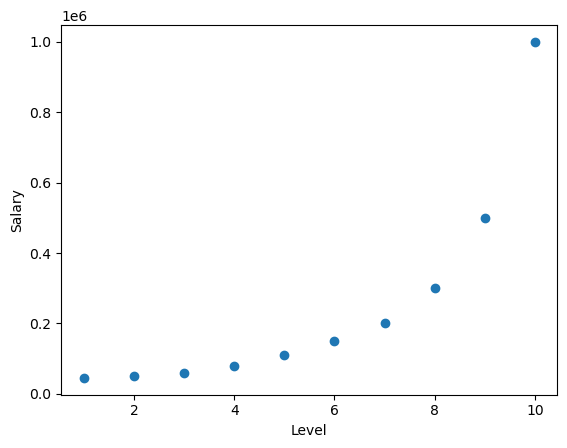

In [207]:
plt.scatter(dataset["Level"], dataset["Salary"])
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

In [208]:
x = dataset[["Level"]]
y = dataset["Salary"]

In [209]:
# convert data into polynomial nature

In [210]:
from sklearn.preprocessing import PolynomialFeatures

In [211]:
pf = PolynomialFeatures(degree=2)
pf.fit(x)

PolynomialFeatures()

In [212]:
x = pf.transform(x)

In [213]:
x

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [214]:
from sklearn.model_selection import train_test_split

In [215]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [216]:
print(x_train)
print(y_train)

[[  1.   6.  36.]
 [  1.   1.   1.]
 [  1.   8.  64.]
 [  1.   3.   9.]
 [  1.  10. 100.]
 [  1.   5.  25.]
 [  1.   4.  16.]
 [  1.   7.  49.]]
5     150000
0      45000
7     300000
2      60000
9    1000000
4     110000
3      80000
6     200000
Name: Salary, dtype: int64


In [217]:
from sklearn.linear_model import LinearRegression

In [218]:
lr = LinearRegression()

In [219]:
lr.fit(x_train, y_train)

LinearRegression()

In [220]:
lr.score(x_test, y_test)*100

76.66492889299867

In [221]:
# y  = m1x1 + m2(x2)^2 + c
# y = -137634.60994912*x1 + 20502.04918033*(x2)^2 + 231288.51045788417

In [222]:
lr.coef_

array([      0.        , -137634.60994912,   20502.04918033])

In [223]:
lr.intercept_

231288.51045788417

In [224]:
prd = lr.predict(x)

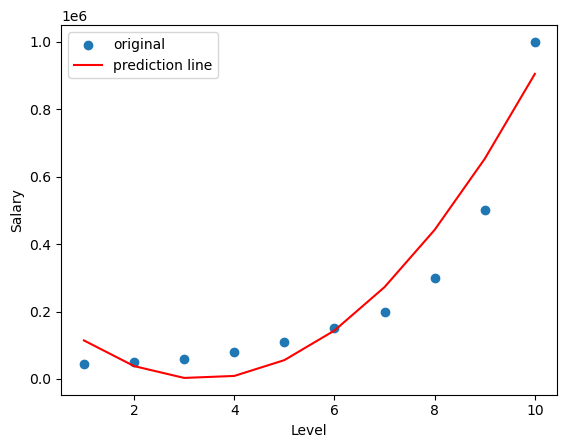

In [225]:
# draw prediction line

plt.scatter(dataset["Level"], dataset["Salary"])
plt.plot(dataset["Level"], prd, c="red")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend(["original", "prediction line"])
plt.show()

In [230]:

test = pf.transform([[1]])
test

/home/satyajit-sahoo/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[1., 1., 1.]])

In [231]:
lr.predict(test)

array([114155.94968909])